In [15]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np
from itertools import product
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../../run")
from run_config import REPO_PATH, SEASONS, PROCESSED_DATA_PATH, FEATURES_PATH
from experiment_config import TARGET_RANGES, TEST_SIZE, RANDOM_STATE, EXPERIMENT_NAME, KEY_COLUMNS

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import align_on_keys
from src.model.model_utils import SklearnWrapper

Matplotlib is building the font cache; this may take a moment.


In [2]:
features_path = f"{FEATURES_PATH}/all_combined_features.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(SEASONS)
target_dfs=[pd.read_csv(f"{PROCESSED_DATA_PATH}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=KEY_COLUMNS).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, KEY_COLUMNS)

In [5]:
feature_df=feature_df.drop(columns=KEY_COLUMNS)
target_df=target_df.drop(columns=KEY_COLUMNS)

In [12]:
def run_multiclass_distribution_experiment(
    feature_df,
    target_df,
    target_ranges,
    model_wrapper_class,
    model_param_grid,
    test_size,
    random_state,
    experiment_name,
    uri,
    model_name
):
    mlflow.set_tracking_uri(uri)
    mlflow.set_experiment(experiment_name)

    X_train, X_test = train_test_split(feature_df, test_size=test_size, random_state=random_state)
    y_train_df = target_df.loc[X_train.index]
    y_test_df = target_df.loc[X_test.index]

    for target_col, (lower_bound, upper_bound) in target_ranges.items():
        print(f"\n--- Training for target: {target_col} ---")
        y_train = y_train_df[target_col]
        y_test = y_test_df[target_col]

        all_classes = sorted(y_train.unique())
        class_to_idx = {c: i for i, c in enumerate(all_classes)}
        idx_to_class = {i: c for c, i in class_to_idx.items()}

        y_train_encoded = y_train.map(class_to_idx)
        y_test_encoded = y_test.map(class_to_idx)

        keys, values = zip(*model_param_grid.items()) if model_param_grid else ([], [])
        for param_combination in product(*values) if values else [()]:
            model_params = dict(zip(keys, param_combination))
            run_name = f"{model_name}_{target_col}_" + "_".join(f"{k}={v}" for k, v in model_params.items())

            with mlflow.start_run(run_name=run_name):
                mlflow.log_param("target", target_col)
                mlflow.log_param("model_name", model_name)
                mlflow.log_params(model_params)

                model = model_wrapper_class(**model_params)
                model.fit(X_train, y_train_encoded)

                proba = model.predict_proba(X_test)
                predicted_class_indices = np.argmax(proba, axis=1)
                predicted_classes = np.array([idx_to_class[i] for i in predicted_class_indices])

                base_acc = accuracy_score(y_test, predicted_classes)
                mlflow.log_metric(f"{target_col}_top1_accuracy", base_acc)

                thresholds = list(range(lower_bound, upper_bound + 1))

                for threshold in thresholds:
                    y_true_binary = (y_test > threshold).astype(int)
                    proba_gt = np.zeros(len(y_test))
                    for cls, idx in class_to_idx.items():
                        if cls > threshold:
                            proba_gt += proba[:, idx]
                    y_pred_binary = (proba_gt >= 0.5).astype(int)
                    acc = accuracy_score(y_true_binary, y_pred_binary)
                    prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
                    mlflow.log_metric(f"{target_col}_gt_{threshold}_accuracy", acc)
                    mlflow.log_metric(f"{target_col}_gt_{threshold}_precision", prec)

                y_true_le = (y_test <= lower_bound).astype(int)
                proba_gt_lb = np.zeros(len(y_test))
                for cls, idx in class_to_idx.items():
                    if cls > lower_bound:
                        proba_gt_lb += proba[:, idx]
                proba_le = 1 - proba_gt_lb
                y_pred_le = (proba_le >= 0.5).astype(int)
                acc_le = accuracy_score(y_true_le, y_pred_le)
                prec_le = precision_score(y_true_le, y_pred_le, zero_division=0)
                mlflow.log_metric(f"{target_col}_lte_{lower_bound}_accuracy", acc_le)
                mlflow.log_metric(f"{target_col}_lte_{lower_bound}_precision", prec_le)

                print(f"Logged metrics for {target_col} with params: {model_params}")

In [55]:
param_grid = {
    'n_estimators': [100,150, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.5],
    'gamma': [0, 1]
}


In [56]:
run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TARGET_RANGES,
    model_wrapper_class=lambda **params: SklearnWrapper(XGBClassifier, **params),
    model_param_grid=param_grid,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    experiment_name=EXPERIMENT_NAME,
    uri=f'{REPO_PATH}/mlflow',
    model_name='XGBClassifier'
)



--- Training for target: home_goals ---
Logged metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0}
Logged metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1}
Logged metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0}
Logged metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1}
Logged metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0}
Logged metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 1}
Logged metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.5, 'gamma': 0}
Logged metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.5, 'gamma': 1}
Logged metrics for home_goals with 

KeyboardInterrupt: 

In [ ]:
def plot_metrics_for_target_and_model(
    experiment_name, target_col, model_name, tracking_uri, metric_prefixes=None, top_n=5
):
    if metric_prefixes is None:
        metric_prefixes = [f"{target_col}_gt_", f"{target_col}_lte_"]

    mlflow.set_tracking_uri(tracking_uri)
    experiment = mlflow.get_experiment_by_name(experiment_name)

    # Search runs
    filter_string = f"params.target = '{target_col}' and params.model_name = '{model_name}'"
    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_string,
        output_format="pandas"
    )

    if runs.empty:
        print("No matching runs found.")
        return

    # Extract metrics for all runs
    metric_rows = []
    for _, run in runs.iterrows():
        run_id = run["run_id"]
        run_name = run.get("tags.mlflow.runName", run_id)
        for k, v in run.items():
            if any((prefix in k) for prefix in metric_prefixes) or k == f"{target_col}_top1_accuracy" or k == f"{target_col}_top1_precision":
                metric_rows.append({
                    "run_name": run_name,
                    "run_id": run_id,
                    "metric_key": k,
                    "metric_value": v
                })

    # Parse metrics into DataFrame
    parsed_metrics = []
    for row in metric_rows:
        k = row["metric_key"]
        v = row["metric_value"]
        run_name = row["run_name"]
        run_id = row["run_id"]
        if k == f"{target_col}_top1_accuracy":
            parsed_metrics.append({
                "run_name": run_name,
                "run_id": run_id,
                "direction": "top1",
                "threshold": None,
                "metric": "accuracy",
                "value": v
            })
        elif k == f"{target_col}_top1_precision":
            parsed_metrics.append({
                "run_name": run_name,
                "run_id": run_id,
                "direction": "top1",
                "threshold": None,
                "metric": "precision",
                "value": v
            })
        elif f"{target_col}_lte_" in k:
            parts = k.split("_")
            threshold = int(parts[-2])
            metric_type = parts[-1]
            parsed_metrics.append({
                "run_name": run_name,
                "run_id": run_id,
                "direction": "lte",
                "threshold": threshold,
                "metric": metric_type,
                "value": v
            })
        elif f"{target_col}_gt_" in k:
            parts = k.split("_")
            threshold = int(parts[-2])
            metric_type = parts[-1]
            parsed_metrics.append({
                "run_name": run_name,
                "run_id": run_id,
                "direction": "gt",
                "threshold": threshold,
                "metric": metric_type,
                "value": v
            })

    metrics_df = pd.DataFrame(parsed_metrics)
    if metrics_df.empty:
        print("No metrics found for plotting.")
        return

    # Compute average accuracy and precision per run
    avg_scores = metrics_df.groupby("run_id").apply(
        lambda df: pd.Series({
            "avg_accuracy": df[df["metric"] == "accuracy"]["value"].mean(),
            "avg_precision": df[df["metric"] == "precision"]["value"].mean(),
            "run_name": df["run_name"].iloc[0]
        })
    ).reset_index()

    # Select top-n runs for accuracy and precision separately
    top_acc_run_ids = avg_scores.nlargest(top_n, "avg_accuracy")["run_id"].tolist()
    top_prec_run_ids = avg_scores.nlargest(top_n, "avg_precision")["run_id"].tolist()

    # Sort for plotting: lte first (increasing threshold), then gt (increasing threshold)
    def sort_key(row):
        if row["direction"] == "lte":
            return (0, row["threshold"] if row["threshold"] is not None else -1)
        elif row["direction"] == "gt":
            return (1, row["threshold"])
        else:
            return (2, -1)
    metrics_df = metrics_df.sort_values(by=["metric", "direction", "threshold"], key=lambda col: [sort_key(row) for _, row in metrics_df.iterrows()])

    # Plot: two plots side by side, one for accuracy, one for precision
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=False)
    metric_types = ["accuracy", "precision"]
    for ax, metric_type, top_run_ids in zip(axes, metric_types, [top_acc_run_ids, top_prec_run_ids]):
        for run_name, group in metrics_df[(metrics_df["metric"] == metric_type) & (metrics_df["run_id"].isin(top_run_ids))].groupby("run_name"):
            lte = group[group["direction"] == "lte"].sort_values("threshold")
            gt = group[group["direction"] == "gt"].sort_values("threshold")
            labels = []
            y = []
            for _, row in lte.iterrows():
                labels.append(f"lte_{row['threshold']}")
                y.append(row["value"])
            for _, row in gt.iterrows():
                labels.append(f"gt_{row['threshold']}")
                y.append(row["value"])
            top1 = group[group["direction"] == "top1"]
            if not top1.empty:
                labels.append("top1")
                y.append(top1.iloc[0]["value"])
            ax.plot(labels, y, marker="o", label=run_name)
        ax.set_title(f"{metric_type.capitalize()} metrics for {target_col} ({model_name}) (Top {top_n})")
        ax.set_xlabel("Metric (ordered: lte, gt, top1)")
        ax.set_ylabel("Score")
        ax.legend(title="Run")
        ax.grid(True)
    plt.tight_layout()
    plt.show()

/var/folders/5j/cgxgswl52bv6qlx0pdt0f8080000gn/T/ipykernel_9417/3802187478.py:131: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


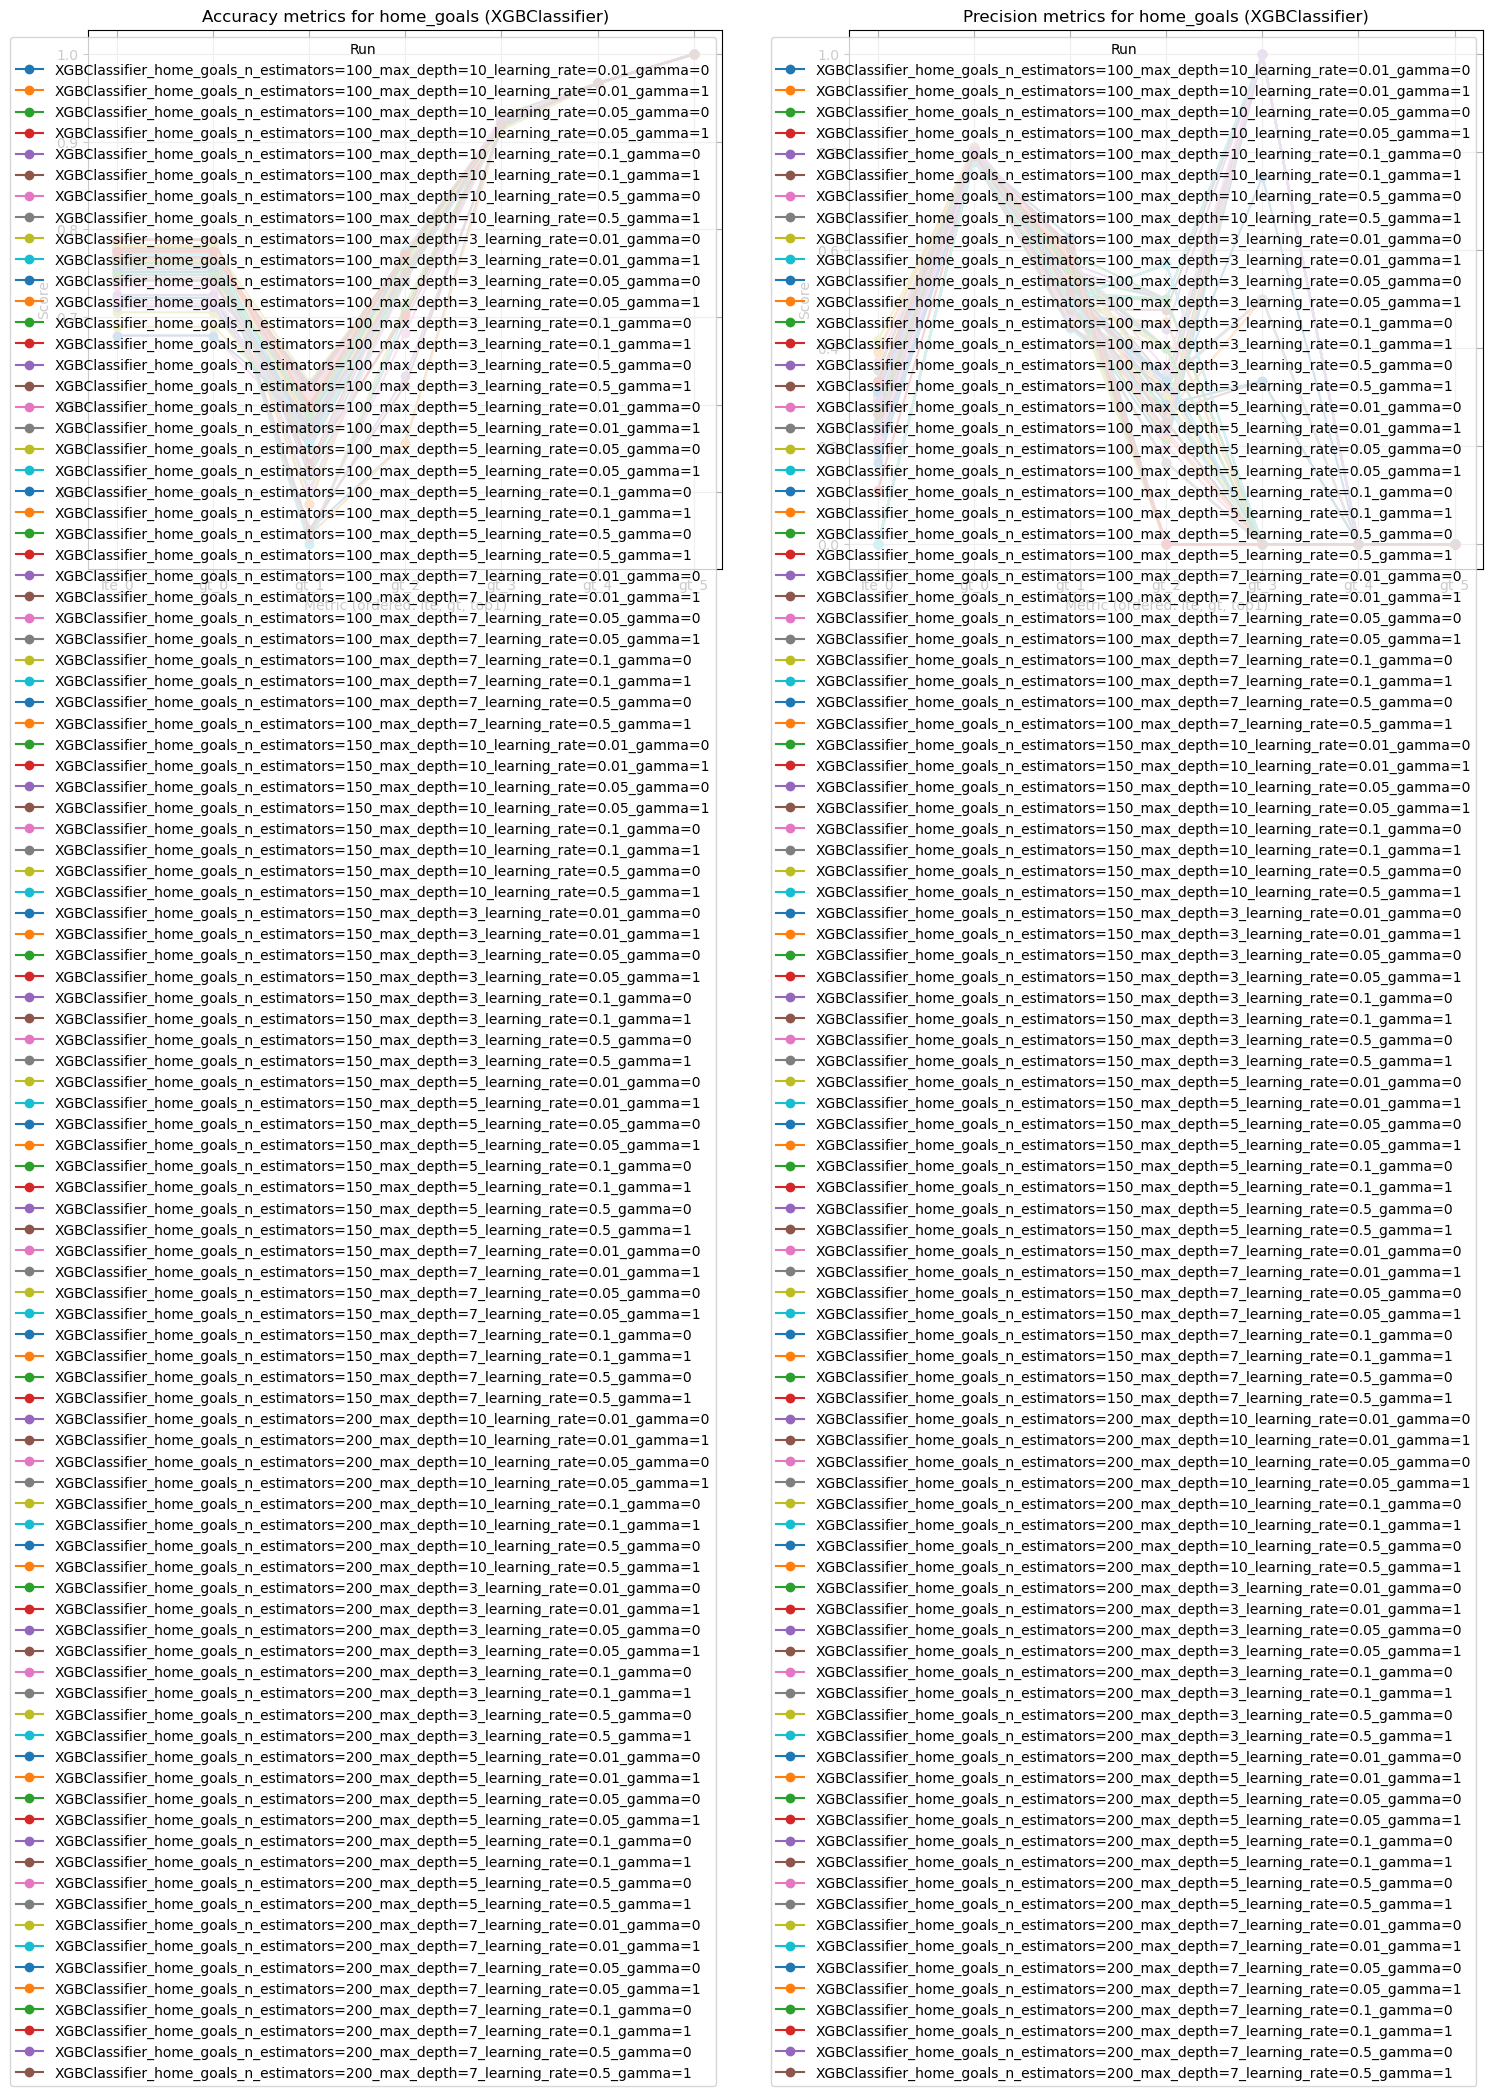

In [57]:
plot_metrics_for_target_and_model(
    experiment_name=EXPERIMENT_NAME,
    target_col="home_goals",
    model_name="XGBClassifier",
    tracking_uri=f"{REPO_PATH}/mlflow"
)